# Source dataset inventory

This notebook creates the initial, reproducible snapshot for the manual dataset audit. It only reads `data/raw`; all generated artifacts are written to `runs/dataset_audit/v1`.

In [3]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / 'data' / 'raw').exists():
    repo_root = repo_root.parent.parent
assert (repo_root / 'data' / 'raw').exists(), 'Run this notebook inside the ML_comp repository'
output_dir = repo_root / 'runs' / 'dataset_audit' / 'v1'
repo_root

PosixPath('/home/irdorat/ML_comp')

## 1. Build the inventory

The command records file hashes, image dimensions, pair counts, and annotation counts. Re-running it overwrites only the generated audit reports, never the source dataset.

In [4]:
result = subprocess.run(
    [sys.executable, str(repo_root / 'scripts' / 'dataset_inventory.py'),
     '--data-root', str(repo_root / 'data' / 'raw'),
     '--output', str(output_dir)],
    cwd=repo_root, check=True, capture_output=True, text=True,
)
summary = json.loads(result.stdout)
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

,value
created_at_utc,2026-08-20T11:41:32.506444+00:00
data_root,/home/irdorat/ML_comp/data/raw
split,train
image_count,4481
label_count,4481
paired_count,4481
images_without_labels,0
labels_without_images,0
object_count,20933
invalid_annotation_rows,0


## 2. Class distribution

,class_id,class_name,object_count,image_count
19,19,A16_FA-18,2147,241
3,3,MS,1994,1188
17,17,A14_KC-135,1424,358
4,4,A1_SU-35,1317,278
5,5,A2_C-130,1297,288
16,16,A13_F-15,1265,211
20,20,A17_TU-95,1114,299
8,8,A5_F-16,1017,240
6,6,A3_C-17,998,257
22,22,A19_SU-34,933,281


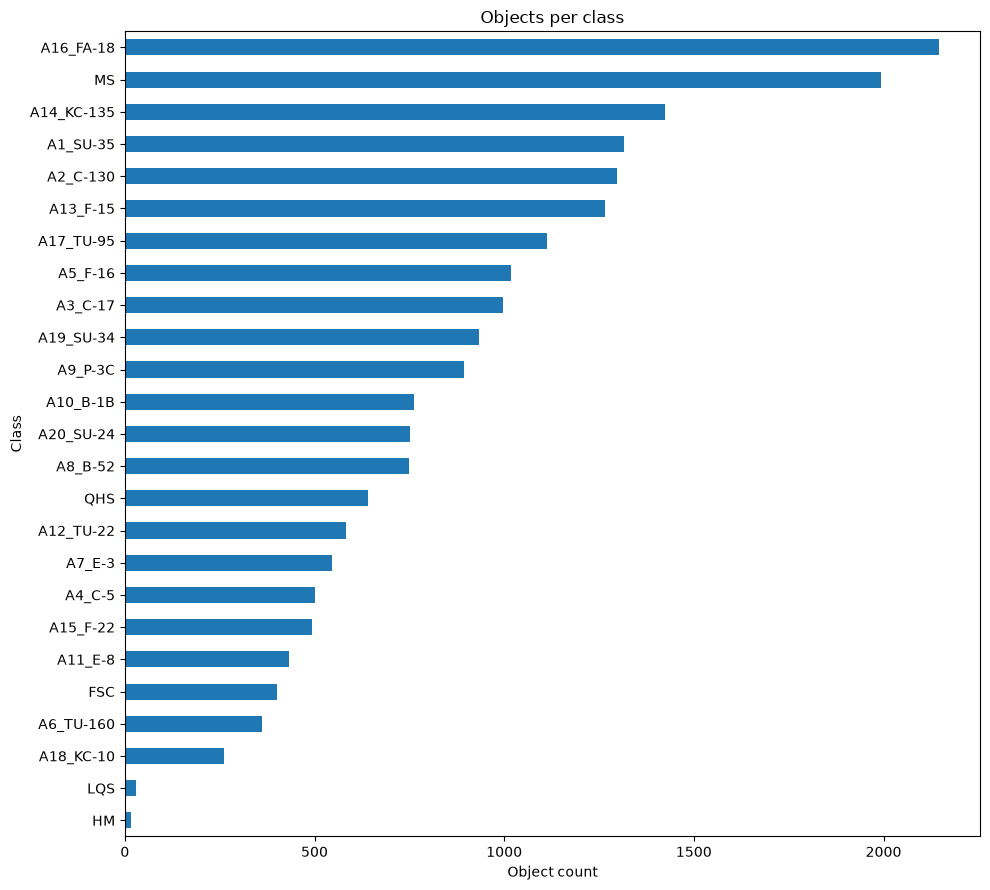

In [5]:
class_stats = pd.read_csv(output_dir / 'class_statistics.csv')
display(class_stats.sort_values('object_count', ascending=False))

ax = class_stats.sort_values('object_count').plot.barh(
    x='class_name', y='object_count', figsize=(10, 9), legend=False,
    title='Objects per class',
)
ax.set_xlabel('Object count')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()

## 3. Rarest classes and file inventory

In [6]:
display(class_stats.nsmallest(10, 'object_count'))

file_inventory = pd.read_csv(output_dir / 'file_inventory.csv')
print(f'Inventory rows: {len(file_inventory):,}')
display(file_inventory.head(10))

,class_id,class_name,object_count,image_count
0,0,HM,17,15
1,1,LQS,30,25
21,21,A18_KC-10,262,82
9,9,A6_TU-160,361,86
24,24,FSC,402,67
14,14,A11_E-8,432,155
18,18,A15_F-22,493,114
7,7,A4_C-5,500,116
10,10,A7_E-3,547,157
15,15,A12_TU-22,583,187


Inventory rows: 4,481


,stem,image_path,label_path,width,height,image_bytes,label_bytes,object_count,image_sha256,label_sha256
0,01-PAN-20240418-318-232-L00000010061-CCD14_3_c...,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,861,861,147952,76,2,100ea258672f78ff57e955f9ff827d68ef647bab384f7a...,69c8bc26f67a169871196f7931e7a4d93854e170c6f47e...
1,01-PAN-20240418-318-232-L00000010061-CCD18_5_c...,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,846,846,168774,37,1,93da99396579ba1de35e0599723511d9d139a09de16ccc...,ceb94f89e130eda95d1299246b9837ff52c955b021488d...
2,01-PAN-20240420-082-358-L00000010818-CCD16_4_c...,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,800,800,71702,76,2,0172ac540b8c7dcb40f361ef9c16a543feed2a5ea05f6a...,84a91580ff71dba37dc78eb3b1bc7485b96a6d4c6d30b2...
3,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop1,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,875,875,241609,76,2,95a7b4d5c842e77a919dc46555d84a25c33f7985e19ec3...,f05e99d2b85d64210bcb98935c5b54d31314649088d7fb...
4,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop4,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,823,823,269334,76,2,7c7f4a18cc3cd10a30ff0d270cd5d3d73e0066e2181b3c...,948ce828a193eb19a6c9d09b6e9678193c279113fdb4c7...
5,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop5,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,823,823,179194,154,4,dc208e6cf73fa4c7c406bc3a561fde8df81154d90d339b...,01037bca24c1170f9e7ed8546748b54cc8022dc68ad8b7...
6,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop6,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,843,843,286010,154,4,bfda81919ffc07a3fadb41404d6b37eac73b14648a2f0a...,b2ab5f5a8bd1d88bfec7c300d97ddf096032b83881b54e...
7,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop7,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,828,828,214763,427,11,10436a1a689ed25c3c1c091a0a75ca3407657aa7c79d5a...,f9b7a2e9a0e0b42b9e2bc3d000eb4b84668d97e66f2da0...
8,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop8,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,883,883,296393,193,5,6477723a576c02f79234ca59fb3c2398e2ea0918f006d7...,7a068dfbe3e6ec28af6ad606047f707a9c7718f4a9f482...
9,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop9,/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...,884,884,239820,193,5,f9ad2c56dcb80e7212e227c58a7b80a21830ed5a35d420...,077a889cef13200e4894453e8207e37582156b04995d5c...


## 4. Automatic dataset validation

This checks image decoding, missing image-label pairs, empty or malformed labels, invalid classes and coordinates, out-of-bounds boxes, and same-class duplicate boxes.

In [7]:
validation = subprocess.run(
    [sys.executable, str(repo_root / 'scripts' / 'validate_dataset.py'),
     '--data-root', str(repo_root / 'data' / 'raw'),
     '--output', str(output_dir),
     '--duplicate-iou', '0.95',
     '--boundary-tolerance', '0.000002',
     '--edge-threshold', '0.001'],
    cwd=repo_root, check=True, capture_output=True, text=True,
)
validation_summary = json.loads(validation.stdout)
display(pd.DataFrame({
    'metric': ['images_checked', 'labels_checked', 'files_with_issues', 'total_issues'],
    'value': [validation_summary[key] for key in
              ['images_checked', 'labels_checked', 'files_with_issues', 'total_issues']],
}))

,metric,value
0,images_checked,4481
1,labels_checked,4481
2,files_with_issues,115
3,total_issues,128


In [8]:
issues = pd.read_csv(output_dir / 'automatic_issues.csv')
if issues.empty:
    print('No automatic validation issues found.')
else:
    issue_counts = (issues.groupby('issue_type').size()
                    .rename('count').sort_values(ascending=False).to_frame())
    display(issue_counts)
    display(issues)

,count
issue_type,
BOX_BOUNDARY_ROUNDING,126
EXACT_DUPLICATE_BOX,2


,stem,issue_type,line_number,detail,image_path,label_path
0,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop5,BOX_BOUNDARY_ROUNDING,1,"xyxy=(-0.000000500, 0.000000500, 0.181044500, ...",/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...
1,01-PAN-20240420-113-325-L00000010882-CCD3_5_crop9,BOX_BOUNDARY_ROUNDING,2,"xyxy=(-0.000000500, 0.937782500, 0.156108500, ...",/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...
2,01-PAN-20240420-113-325-L00000010882-CCD3_6_crop3,BOX_BOUNDARY_ROUNDING,2,"xyxy=(-0.000000500, 0.361045000, 0.051068500, ...",/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...
3,01-PAN-20240506-094-666-L00000012249-CCD11_6_c...,BOX_BOUNDARY_ROUNDING,3,"xyxy=(0.091334500, -0.000000500, 0.446135500, ...",/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...
4,01-PAN-20240506-094-666-L00000012249-CCD11_6_c...,BOX_BOUNDARY_ROUNDING,1,"xyxy=(0.404481000, -0.000000500, 0.616745000, ...",/home/irdorat/ML_comp/data/raw/images/train/01...,/home/irdorat/ML_comp/data/raw/labels/train/01...
...,...,...,...,...,...,...
123,fsc_TG-N22.33-E120.62-lv20-Bing_crop0003,BOX_BOUNDARY_ROUNDING,3,"xyxy=(0.681111500, -0.000000500, 0.732222500, ...",/home/irdorat/ML_comp/data/raw/images/train/fs...,/home/irdorat/ML_comp/data/raw/labels/train/fs...
124,fsc_TG-N22.33-E120.62-lv20-Google_crop0002,BOX_BOUNDARY_ROUNDING,6,"xyxy=(0.988889000, -0.000000500, 0.998889000, ...",/home/irdorat/ML_comp/data/raw/images/train/fs...,/home/irdorat/ML_comp/data/raw/labels/train/fs...
125,fsc_TG-N22.33-E120.62-lv20-Google_crop0002,EXACT_DUPLICATE_BOX,3,"lines=2,3; class_id=24; IoU=1.000000",/home/irdorat/ML_comp/data/raw/images/train/fs...,/home/irdorat/ML_comp/data/raw/labels/train/fs...
126,fsc_TG-N24.21-E120.59-lv20-Google_crop0002,BOX_BOUNDARY_ROUNDING,5,"xyxy=(-0.000000500, 0.233333000, 0.026666500, ...",/home/irdorat/ML_comp/data/raw/images/train/fs...,/home/irdorat/ML_comp/data/raw/labels/train/fs...


## 5. Visual annotation review

Boxes are drawn in memory and displayed in the notebook. The source images are not changed. Each label contains the annotation line number and class name, for example `#3 A14_KC-135`.

In [9]:
from math import ceil
from PIL import Image
from matplotlib.patches import Rectangle

CLASS_NAMES = [
    'HM', 'LQS', 'QHS', 'MS', 'A1_SU-35', 'A2_C-130', 'A3_C-17',
    'A4_C-5', 'A5_F-16', 'A6_TU-160', 'A7_E-3', 'A8_B-52',
    'A9_P-3C', 'A10_B-1B', 'A11_E-8', 'A12_TU-22', 'A13_F-15',
    'A14_KC-135', 'A15_F-22', 'A16_FA-18', 'A17_TU-95',
    'A18_KC-10', 'A19_SU-34', 'A20_SU-24', 'FSC',
]

def read_yolo_labels(label_path):
    boxes = []
    for line_number, line in enumerate(Path(label_path).read_text().splitlines(), 1):
        fields = line.split()
        if len(fields) != 5:
            continue
        class_id = int(fields[0])
        x, y, width, height = map(float, fields[1:])
        boxes.append((line_number, class_id, x, y, width, height))
    return boxes

def draw_annotation(stem, ax=None, highlight_lines=None):
    highlight_lines = set(highlight_lines or [])
    row = file_inventory.loc[file_inventory['stem'] == stem]
    if row.empty:
        raise KeyError(f'Unknown image stem: {stem}')
    row = row.iloc[0]
    image = Image.open(row.image_path).convert('RGB')
    width, height = image.size
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    colors = plt.colormaps['tab20']
    for line_no, class_id, x, y, box_w, box_h in read_yolo_labels(row.label_path):
        x1 = (x - box_w / 2) * width
        y1 = (y - box_h / 2) * height
        highlighted = line_no in highlight_lines
        color = 'red' if highlighted else colors(class_id % 20)
        ax.add_patch(Rectangle(
            (x1, y1), box_w * width, box_h * height,
            fill=False, edgecolor=color, linewidth=4 if highlighted else 2,
        ))
        ax.text(
            max(0, x1), max(0, y1), f"#{line_no} {CLASS_NAMES[class_id]}{' EDGE' if highlighted else ''}",
            color='white', fontsize=8, verticalalignment='top',
            bbox={'facecolor': color, 'alpha': 0.85, 'pad': 2, 'edgecolor': 'none'},
        )
    ax.set_title(stem)
    ax.axis('off')
    return ax

def show_batch(stems, columns=2, figsize_per_image=6):
    stems = list(stems)
    if not stems:
        print('This review queue is empty.')
        return
    rows = ceil(len(stems) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(columns * figsize_per_image, rows * figsize_per_image))
    axes = [axes] if rows * columns == 1 else list(axes.flat)
    for ax, stem in zip(axes, stems):
        draw_annotation(stem, ax)
    for ax in axes[len(stems):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def show_edge_batch(edge_table, stems, columns=2, figsize_per_image=6):
    stems = list(stems)
    if not stems:
        print('This review queue is empty.')
        return
    rows = ceil(len(stems) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(columns * figsize_per_image, rows * figsize_per_image))
    axes = [axes] if rows * columns == 1 else list(axes.flat)
    for ax, stem in zip(axes, stems):
        lines = edge_table.loc[edge_table.stem == stem, 'line_number'].astype(int).tolist()
        draw_annotation(stem, ax, highlight_lines=lines)
    for ax in axes[len(stems):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Review queue A: automatic issues

Change `start` to move through the queue. Boundary-rounding warnings are excluded by default because they are not visually meaningful.

Actionable issue images: 2; showing 0:6


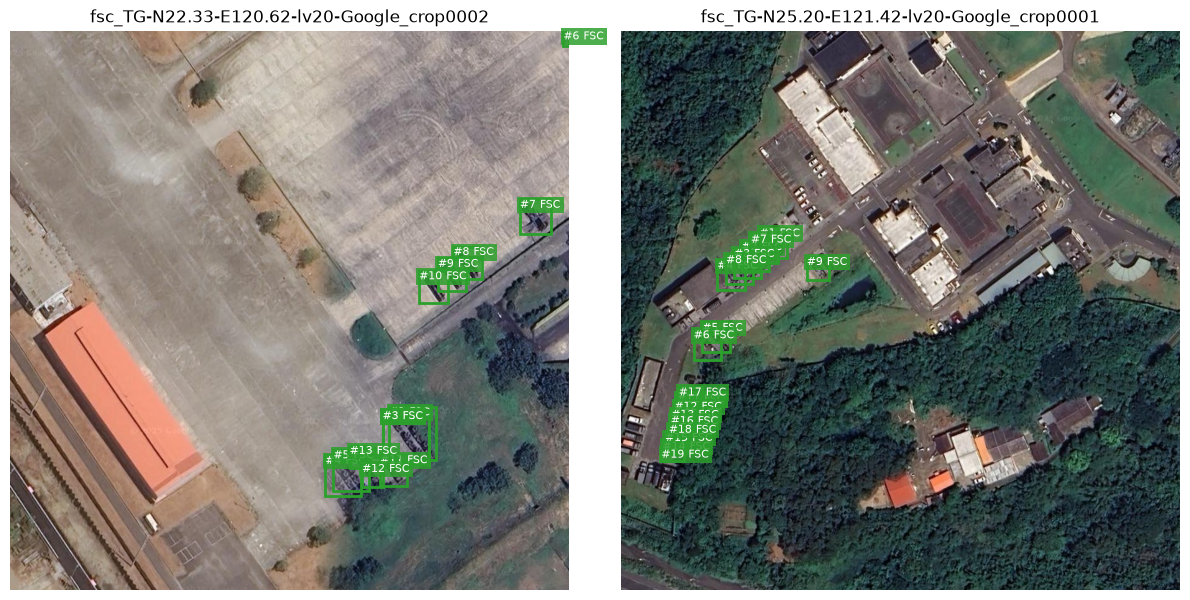

In [10]:
actionable_issues = issues[issues.issue_type != 'BOX_BOUNDARY_ROUNDING']
issue_stems = actionable_issues.stem.drop_duplicates().tolist()
start, batch_size = 0, 6
print(f'Actionable issue images: {len(issue_stems)}; showing {start}:{start + batch_size}')
show_batch(issue_stems[start:start + batch_size])

### Review queue B: rare classes

Set `rare_class_ids` explicitly according to the agreed rare-class definition. The initial values below cover the three least frequent classes.

Rare-class images: 120; showing 0:6
MAR20_1043
MAR20_1075
MAR20_1114
MAR20_1320
MAR20_1338
MAR20_1384


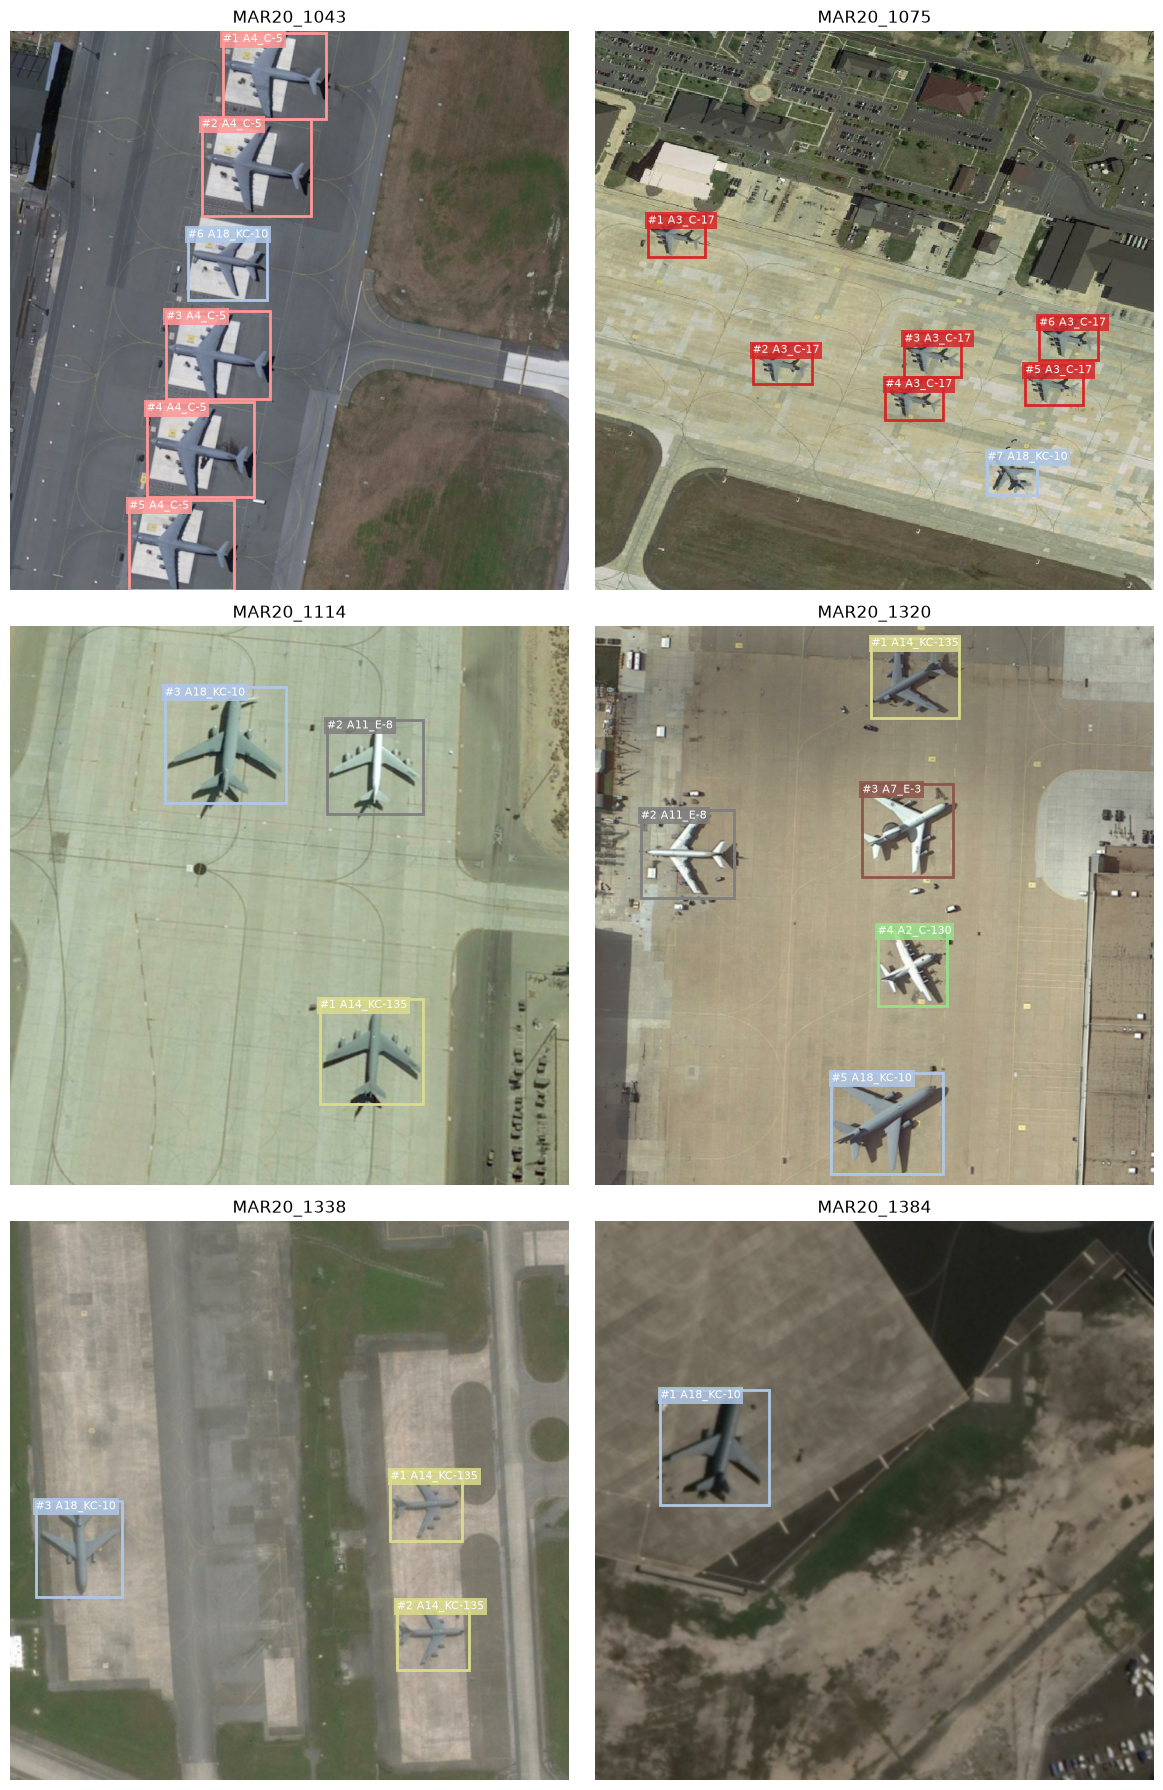

In [11]:
rare_class_ids = {0, 1, 21}  # HM, LQS, A18_KC-10
rare_records = []
for row in file_inventory.itertuples():
    present = {box[1] for box in read_yolo_labels(row.label_path)}
    matched = sorted(present & rare_class_ids)
    if matched:
        rare_records.append({
            'stem': row.stem,
            'image_path': row.image_path,
            'rare_class_ids': ', '.join(map(str, matched)),
            'rare_classes': ', '.join(CLASS_NAMES[class_id] for class_id in matched),
        })
rare_images = pd.DataFrame(rare_records).sort_values(['rare_classes', 'stem']).reset_index(drop=True)
rare_stems = rare_images.stem.tolist()
start, batch_size = 0, 6
batch_stems = rare_stems[start:start + batch_size]
print(f'Rare-class images: {len(rare_stems)}; showing {start}:{start + len(batch_stems)}')
print('\n'.join(batch_stems))
show_batch(batch_stems)

### Review queue D: boxes touching an image edge

These are review candidates, not confirmed errors. A truncated object may be correctly annotated. `touching_edges` identifies the relevant side of the image.

Images with edge boxes: 691; showing 400:401
MAR20_1682


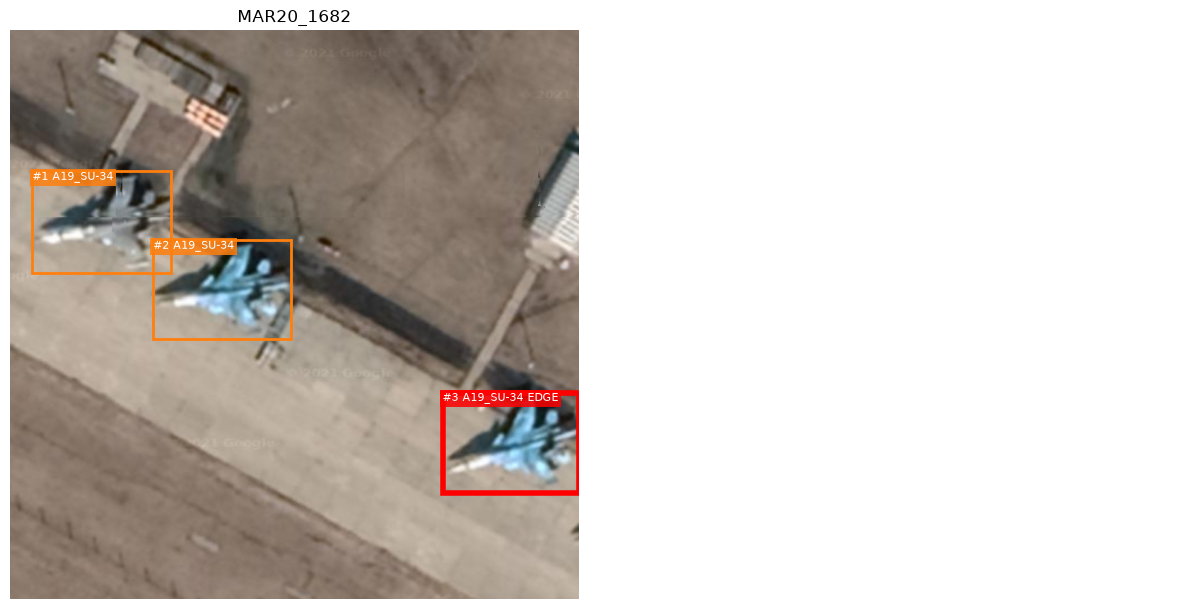

In [12]:
edge_candidates = pd.read_csv(output_dir / 'edge_box_candidates.csv')
edge_stems = edge_candidates.stem.drop_duplicates().tolist()
n=400
start, batch_size = n, 1
batch_stems = edge_stems[start:start + batch_size]
print(f'Images with edge boxes: {len(edge_stems)}; showing {start}:{start + len(batch_stems)}')
print('\n'.join(batch_stems))
show_edge_batch(edge_candidates, batch_stems)

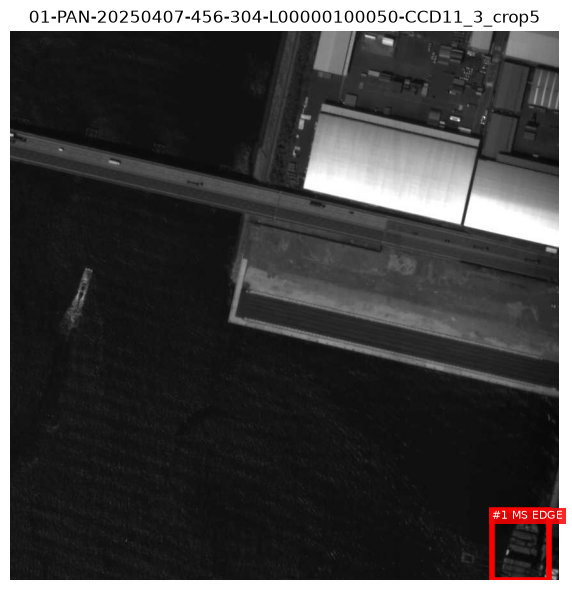

In [13]:
image_name = '01-PAN-20250407-456-304-L00000100050-CCD11_3_crop5'
show_edge_batch(edge_candidates, [image_name], columns=1)

## Interpretation

At this stage, zero missing pairs and zero invalid rows mean that the dataset structure and basic YOLO syntax are consistent. They do **not** prove that class labels or bounding boxes are visually correct; those checks belong to the next audit stages.